# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [8]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Ganti path ini sesuai lokasi file heart.csv kamu
RAW_DATA_PATH = '.././heart_disease/heart_disease_uci.csv'

# Periksa apakah file ada dan baca data
if os.path.exists(RAW_DATA_PATH):
    df = pd.read_csv(RAW_DATA_PATH, sep=',')
    
    print("Data berhasil dimuat. Berikut 5 baris pertama:")
    print(df.head())
else:
    print(f"File tidak ditemukan di {RAW_DATA_PATH}. Silakan upload dataset heart.csv terlebih dahulu.")

Data berhasil dimuat. Berikut 5 baris pertama:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             nor

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

--- Statistik Deskriptif ---
               id         age    trestbps        chol      thalch     ol

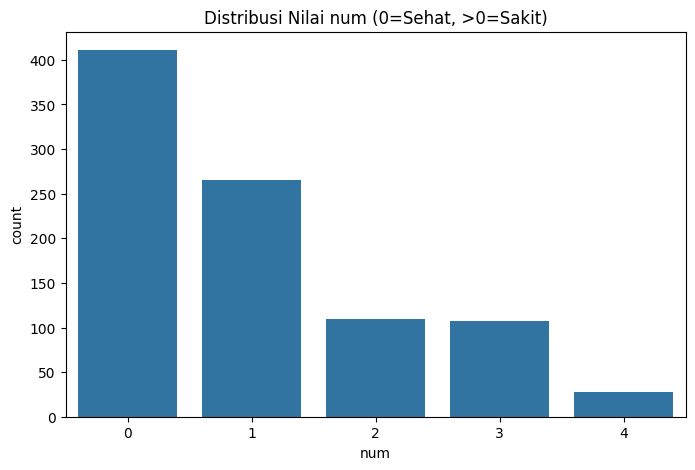

In [7]:
if 'df' in locals():
    # 1. Info Dasar
    print("\n--- Info Dataset ---")
    print(df.info())

    # 2. Statistik
    print("\n--- Statistik Deskriptif ---")
    print(df.describe())

    # 3. Cek Missing Values
    print("\n--- Cek Missing Values ---")
    print(df.isnull().sum())

    # 4. Visualisasi Target
    # Di dataset mentah, target biasanya bernama 'num' (0=sehat, 1-4=sakit)
    # Atau kadang sudah bernama 'target' tergantung sumber downloadnya
    target_col = 'num' if 'num' in df.columns else 'target'
    
    if target_col in df.columns:
        print(f"\n--- Visualisasi Kolom Target ({target_col}) ---")
        plt.figure(figsize=(8, 5))
        sns.countplot(x=target_col, data=df)
        plt.title(f'Distribusi Nilai {target_col} (0=Sehat, >0=Sakit)')
        plt.show()
    else:
        print("Kolom target ('num' atau 'target') tidak ditemukan.")

else:
    print("Jalankan cell 'Memuat Dataset' dulu.")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:


if 'df' in locals():
    print("Memulai Preprocessing Heart Disease...")
    df_processed = df.copy()

    # 1. HAPUS KOLOM TIDAK BERGUNA
    if 'id' in df_processed.columns:
        df_processed.drop('id', axis=1, inplace=True)
        print("- Kolom 'id' dihapus.")

    # 2. HANDLING TARGET ('num' -> 'target' biner)
    # Jika target masih berupa angka 0-4 ('num'), ubah jadi 0 (Sehat) dan 1 (Sakit)
    if 'num' in df_processed.columns:
        df_processed['target'] = df_processed['num'].apply(lambda x: 1 if x > 0 else 0)
        df_processed.drop('num', axis=1, inplace=True)
        print("- Mengubah 'num' (0-4) menjadi 'target' (0/1).")
    
    # 3. HANDLING MISSING VALUES
    # Isi data kosong dengan rata-rata (numeric only untuk menghindari error)
    numeric_means = df_processed.mean(numeric_only=True)
    df_processed.fillna(numeric_means, inplace=True)
    print("- Missing values diisi dengan rata-rata.")

    # 4. ENCODING KATEGORIKAL (One-Hot Encoding)
    # Kolom seperti 'cp', 'thal', 'slope' adalah kategori meskipun angkanya urut
    categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'origin']
    
    # Deteksi kolom object (teks) juga
    object_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
    cols_to_encode = list(set(object_cols + [c for c in categorical_cols if c in df_processed.columns]))
    
    if cols_to_encode:
        df_processed = pd.get_dummies(df_processed, columns=cols_to_encode, drop_first=True)
        print(f"- Melakukan One-Hot Encoding pada: {cols_to_encode}")

    # 5. SCALING NUMERIK (StandardScaler)
    # Agar umur (puluhan) dan kolesterol (ratusan) punya skala setara
    scaler = StandardScaler()
    numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    existing_num_cols = [col for col in numerical_cols if col in df_processed.columns]
    
    if existing_num_cols:
        df_processed[existing_num_cols] = scaler.fit_transform(df_processed[existing_num_cols])
        print(f"- Melakukan Scaling pada: {existing_num_cols}")

    print("\nPreprocessing Selesai!")
    print("Dimensi Data Baru:", df_processed.shape)
    print(df_processed.head())

else:
    print("Dataframe belum dimuat.")

Memulai Preprocessing Heart Disease...
- Kolom 'id' dihapus.
- Mengubah 'num' (0-4) menjadi 'target' (0/1).
- Missing values diisi dengan rata-rata.
- Melakukan One-Hot Encoding pada: ['restecg', 'slope', 'cp', 'exang', 'sex', 'fbs', 'thal', 'dataset']
- Melakukan Scaling pada: ['age', 'trestbps', 'chol', 'oldpeak']

Preprocessing Selesai!
Dimensi Data Baru: (920, 22)
        age  trestbps      chol  thalch   oldpeak   ca  target  \
0  1.007386  0.698041  0.311021   150.0  1.349421  0.0       0   
1  1.432034  1.511761  0.797713   108.0  0.589832  3.0       1   
2  1.432034 -0.658158  0.274289   129.0  1.634267  2.0       1   
3 -1.752828 -0.115679  0.467130   187.0  2.488805  0.0       0   
4 -1.328180 -0.115679  0.044717   172.0  0.494884  0.0       0   

   restecg_normal  restecg_st-t abnormality  slope_flat  ...  cp_non-anginal  \
0           False                     False       False  ...           False   
1           False                     False        True  ...           F

In [12]:

output_path = "data/processed/heart_processed.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
print(f"Menyimpan data bersih ke: {output_path}")
df_processed.to_csv(output_path, index=False)
print("Data bersih berhasil disimpan.")

Menyimpan data bersih ke: data/processed/heart_processed.csv
Data bersih berhasil disimpan.
